# UIDAI AADHAR LENS HACKATHON

## Problem Statement

AadhaarLens: Where Does Aadhaar Activity Actually Happen?"
Identifying Aadhaar service demand patterns across time, age groups, and geography — and using them to classify districts as still-growing (need enrolment camps) or already-mature (need update/maintenance camps), with a scan for unusual activity days worth investigating.


## Columns and its meaning

- Unnamed: 0    Extra index/serial number column created during CSV export. Not useful for analysis; can be removed.
- date: Date on which Aadhaar activity was recorded.
- state: State/Union Territory where the Aadhaar activity occurred.
- district: District where the Aadhaar activity occurred.
- pincode: PIN code of the location where the activity was recorded.
- age_0_5: Number of new Aadhaar enrolments for children aged 0–5 years.
- age_5_17: Number of new Aadhaar enrolments for individuals aged 5–17 years.
- age_18_greater: Number of new Aadhaar enrolments for individuals aged 18 years and above.
- demo_age_5_17: Number of demographic updates for individuals aged 5–17 years.
- demo_age17: Number of demographic updates for individuals aged 18 years and above.
- bio_age_5_17: Number of biometric updates for individuals aged 5–17 years.
- bio_age17: Number of biometric updates for individuals aged 18 years and above.

## Import IMP Libraries 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"C:\Users\mohit\Downloads\Mobile Devices\UIDAI.csv")

In [3]:
df.head()

,Unnamed: 0,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


In [4]:
df.shape

(94955, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94955 entries, 0 to 94954
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      94955 non-null  int64 
 1   date            94955 non-null  object
 2   state           94955 non-null  object
 3   district        94955 non-null  object
 4   pincode         94955 non-null  int64 
 5   age_0_5         94955 non-null  int64 
 6   age_5_17        94955 non-null  int64 
 7   age_18_greater  94955 non-null  int64 
 8   demo_age_5_17   94955 non-null  int64 
 9   demo_age_17_    94955 non-null  int64 
 10  bio_age_5_17    94955 non-null  int64 
 11  bio_age_17_     94955 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 8.7+ MB


In [6]:
df.describe()

,Unnamed: 0,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
count,94955.000000,94955.00000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000
mean,47477.000000,516986.25906,4.315802,2.028929,0.106250,3.524585,28.831099,15.804655,14.014270
std,27411.291743,206818.78222,29.076013,16.433080,1.450567,23.669851,184.133758,86.564516,89.234521
min,0.000000,110001.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,23738.500000,363423.00000,1.000000,0.000000,0.000000,0.000000,5.000000,2.000000,3.000000
50%,47477.000000,509408.00000,2.000000,1.000000,0.000000,1.000000,12.000000,5.000000,6.000000
75%,71215.500000,711403.50000,4.000000,2.000000,0.000000,3.000000,26.000000,14.000000,13.000000
max,94954.000000,855117.00000,2688.000000,1351.000000,151.000000,1883.000000,14732.000000,5854.000000,7201.000000


In [7]:
# Remove the old "Unnamed: 0" column and add a clean serial number starting from 1
df = df.drop(columns=['Unnamed: 0'])

df.insert(0, 'sr.no', range(1, len(df) + 1))

df.head()

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426


In [8]:
df.columns

Index(['sr.no', 'date', 'state', 'district', 'pincode', 'age_0_5', 'age_5_17',
       'age_18_greater', 'demo_age_5_17', 'demo_age_17_', 'bio_age_5_17',
       'bio_age_17_'],
      dtype='object')

In [9]:
df.dtypes

sr.no              int64
date              object
state             object
district          object
pincode            int64
age_0_5            int64
age_5_17           int64
age_18_greater     int64
demo_age_5_17      int64
demo_age_17_       int64
bio_age_5_17       int64
bio_age_17_        int64
dtype: object

In [10]:
df['date'] = pd.to_datetime(df['date'])

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94955 entries, 0 to 94954
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   sr.no           94955 non-null  int64         
 1   date            94955 non-null  datetime64[ns]
 2   state           94955 non-null  object        
 3   district        94955 non-null  object        
 4   pincode         94955 non-null  int64         
 5   age_0_5         94955 non-null  int64         
 6   age_5_17        94955 non-null  int64         
 7   age_18_greater  94955 non-null  int64         
 8   demo_age_5_17   94955 non-null  int64         
 9   demo_age_17_    94955 non-null  int64         
 10  bio_age_5_17    94955 non-null  int64         
 11  bio_age_17_     94955 non-null  int64         
dtypes: datetime64[ns](1), int64(9), object(2)
memory usage: 8.7+ MB


In [12]:
df['state'].nunique()
df['state'].value_counts()

state
Uttar Pradesh                               10122
Maharashtra                                  8321
Tamil Nadu                                   7295
Karnataka                                    6975
West Bengal                                  6740
Andhra Pradesh                               5823
Rajasthan                                    5649
Bihar                                        5613
Madhya Pradesh                               5174
Odisha                                       5048
Gujarat                                      4425
Telangana                                    3710
Kerala                                       3498
Assam                                        3104
Jharkhand                                    2381
Punjab                                       2176
Chhattisgarh                                 1644
Haryana                                      1637
Jammu and Kashmir                            1037
Himachal Pradesh                            

In [13]:
df['state'] = df['state'].str.strip().str.replace('&','and')
df['state'] = df['state'].str.replace('Orissa','Odisha')
df['state'] = df['state'].replace({
    'Pondicherry': 'Puducherry',
    'Westbengal': 'West Bengal',
    'andhra pradesh': 'Andhra Pradesh'
})

In [14]:
df['state'].value_counts()

state
Uttar Pradesh                               10122
Maharashtra                                  8321
Tamil Nadu                                   7295
Karnataka                                    6975
West Bengal                                  6741
Andhra Pradesh                               5824
Rajasthan                                    5649
Bihar                                        5613
Odisha                                       5267
Madhya Pradesh                               5174
Gujarat                                      4425
Telangana                                    3710
Kerala                                       3498
Assam                                        3104
Jharkhand                                    2381
Punjab                                       2176
Chhattisgarh                                 1644
Haryana                                      1637
Jammu and Kashmir                            1040
Himachal Pradesh                            

In [15]:
df['district'].value_counts()

district
Pune                 731
North 24 Parganas    601
Bengaluru            561
Nashik               478
Barddhaman           476
                    ... 
Dibang Valley          1
Samstipur              1
Kamle                  1
Sribhumi               1
Pandhurna              1
Name: count, Length: 880, dtype: int64

In [16]:
df['district']=df['district'].str.strip().str.title().str.replace('*','')

In [17]:
df['district'].value_counts()

district
Pune                 731
North 24 Parganas    601
Bengaluru            561
Nashik               478
Barddhaman           476
                    ... 
Samstipur              1
Sribhumi               1
Washim                 1
Niuland                1
Bengaluru South        1
Name: count, Length: 875, dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.isnull().sum()

sr.no             0
date              0
state             0
district          0
pincode           0
age_0_5           0
age_5_17          0
age_18_greater    0
demo_age_5_17     0
demo_age_17_      0
bio_age_5_17      0
bio_age_17_       0
dtype: int64

In [20]:
df['total_enrolment'] = (
    df['age_0_5'] +
    df['age_5_17'] +
    df['age_18_greater']
)
df

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117
...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,94951,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1
94951,94952,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16
94952,94953,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4
94953,94954,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5


In [21]:
df['total_demo_updates'] = (
    df['demo_age_5_17'] +
    df['demo_age_17_']
)
df

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114,555
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173,664
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342,1243
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402,2176
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117,1841
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,94951,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1,52
94951,94952,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16,50
94952,94953,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4,54
94953,94954,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5,24


In [22]:
df['total_bio_updates'] = (
    df['bio_age_5_17'] +
    df['bio_age_17_']
)
df

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates,total_bio_updates
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114,555,464
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173,664,479
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342,1243,2742
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402,2176,3358
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117,1841,968
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,94951,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1,52,49
94951,94952,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16,50,150
94952,94953,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4,54,43
94953,94954,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5,24,58


In [23]:
df['total_updates'] = (
    df['total_demo_updates'] +
    df['total_bio_updates']
)
df

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates,total_bio_updates,total_updates
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114,555,464,1019
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173,664,479,1143
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342,1243,2742,3985
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402,2176,3358,5534
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117,1841,968,2809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,94951,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1,52,49,101
94951,94952,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16,50,150,200
94952,94953,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4,54,43,97
94953,94954,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5,24,58,82


In [24]:
df['total_activity'] = (
    df['total_enrolment'] +
    df['total_updates']
)
df

,sr.no,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates,total_bio_updates,total_updates,total_activity
0,1,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114,555,464,1019,1133
1,2,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173,664,479,1143,1316
2,3,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342,1243,2742,3985,4327
3,4,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402,2176,3358,5534,5936
4,5,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117,1841,968,2809,2926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,94951,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1,52,49,101,102
94951,94952,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16,50,150,200,216
94952,94953,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4,54,43,97,101
94953,94954,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5,24,58,82,87


In [25]:
df.describe()

,sr.no,date,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates,total_bio_updates,total_updates,total_activity
count,94955.000000,94955,94955.00000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000,94955.000000
mean,47478.000000,2025-09-09 12:35:05.064504064,516986.25906,4.315802,2.028929,0.106250,3.524585,28.831099,15.804655,14.014270,6.450982,32.355684,29.818925,62.174609,68.625591
min,1.000000,2025-04-01 00:00:00,110001.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,2.000000
25%,23739.500000,2025-09-05 00:00:00,363423.00000,1.000000,0.000000,0.000000,0.000000,5.000000,2.000000,3.000000,1.000000,6.000000,5.000000,13.000000,15.000000
50%,47478.000000,2025-09-10 00:00:00,509408.00000,2.000000,1.000000,0.000000,1.000000,12.000000,5.000000,6.000000,3.000000,13.000000,12.000000,28.000000,32.000000
75%,71216.500000,2025-09-15 00:00:00,711403.50000,4.000000,2.000000,0.000000,3.000000,26.000000,14.000000,13.000000,6.000000,29.000000,28.000000,60.000000,66.000000
max,94955.000000,2025-09-19 00:00:00,855117.00000,2688.000000,1351.000000,151.000000,1883.000000,14732.000000,5854.000000,7201.000000,3965.000000,16130.000000,12204.000000,28298.000000,30000.000000
std,27411.291743,NaN,206818.78222,29.076013,16.433080,1.450567,23.669851,184.133758,86.564516,89.234521,45.303259,206.259114,170.304916,367.455275,410.105919


In [26]:
df['date'].unique()

<DatetimeArray>
['2025-04-01 00:00:00', '2025-05-01 00:00:00', '2025-06-01 00:00:00',
 '2025-07-01 00:00:00', '2025-09-01 00:00:00', '2025-09-02 00:00:00',
 '2025-09-03 00:00:00', '2025-09-04 00:00:00', '2025-09-05 00:00:00',
 '2025-09-06 00:00:00', '2025-09-07 00:00:00', '2025-09-08 00:00:00',
 '2025-09-09 00:00:00', '2025-09-10 00:00:00', '2025-09-11 00:00:00',
 '2025-09-12 00:00:00', '2025-09-13 00:00:00', '2025-09-14 00:00:00',
 '2025-09-15 00:00:00', '2025-09-16 00:00:00', '2025-09-17 00:00:00',
 '2025-09-18 00:00:00', '2025-09-19 00:00:00']
Length: 23, dtype: datetime64[ns]

In [27]:
df.drop(columns=['sr.no'], inplace=True)

In [28]:
df

,date,state,district,pincode,age_0_5,age_5_17,age_18_greater,demo_age_5_17,demo_age_17_,bio_age_5_17,bio_age_17_,total_enrolment,total_demo_updates,total_bio_updates,total_updates,total_activity
0,2025-04-01,Tamil Nadu,Kancheepuram,600045,81,19,14,53,502,193,271,114,555,464,1019,1133
1,2025-04-01,Rajasthan,Jhalawar,326038,112,49,12,76,588,152,327,173,664,479,1143,1316
2,2025-04-01,Madhya Pradesh,Raisen,464551,291,39,12,213,1030,1989,753,342,1243,2742,3985,4327
3,2025-04-01,Madhya Pradesh,Dhar,454001,253,74,75,372,1804,1775,1583,402,2176,3358,5534,5936
4,2025-04-01,Chandigarh,Chandigarh,160036,86,21,10,400,1441,542,426,117,1841,968,2809,2926
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94950,2025-09-19,Delhi,South Delhi,110017,1,0,0,4,48,17,32,1,52,49,101,102
94951,2025-09-19,Delhi,North West Delhi,110081,15,1,0,12,38,70,80,16,50,150,200,216
94952,2025-09-19,Delhi,North West Delhi,110052,4,0,0,6,48,25,18,4,54,43,97,101
94953,2025-09-19,Delhi,North West Delhi,110036,4,1,0,1,23,23,35,5,24,58,82,87


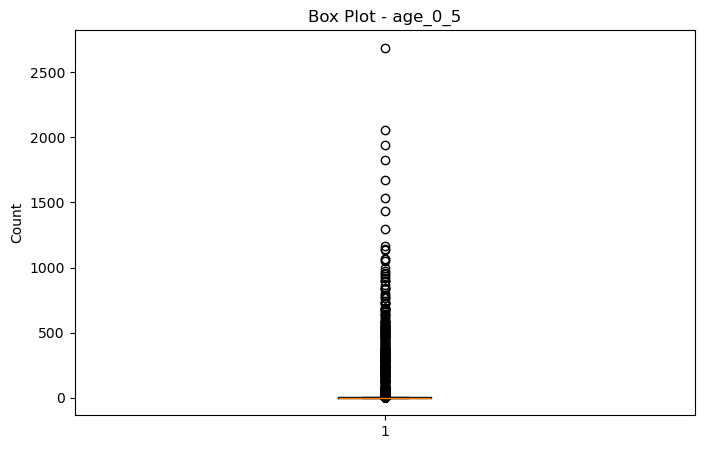

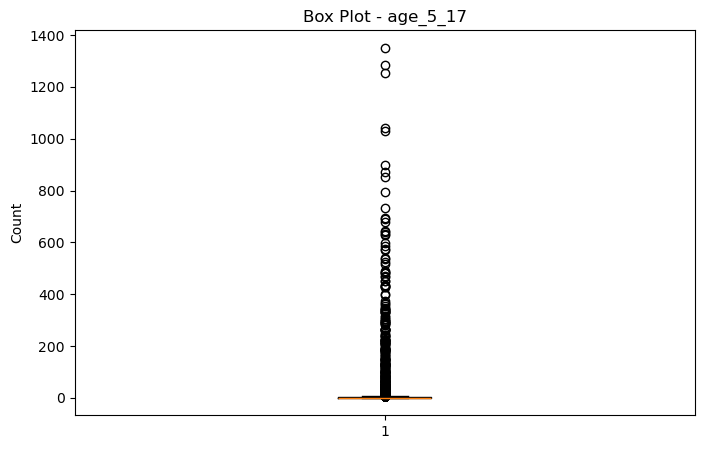

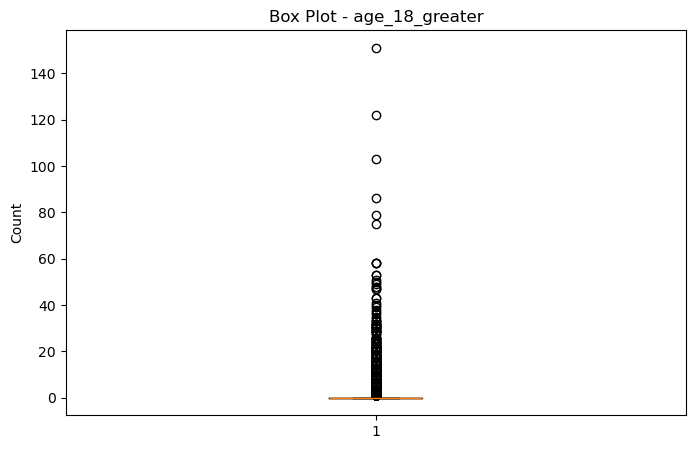

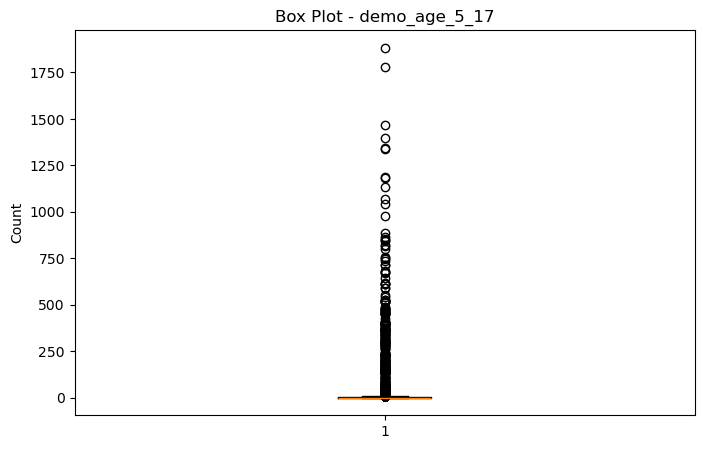

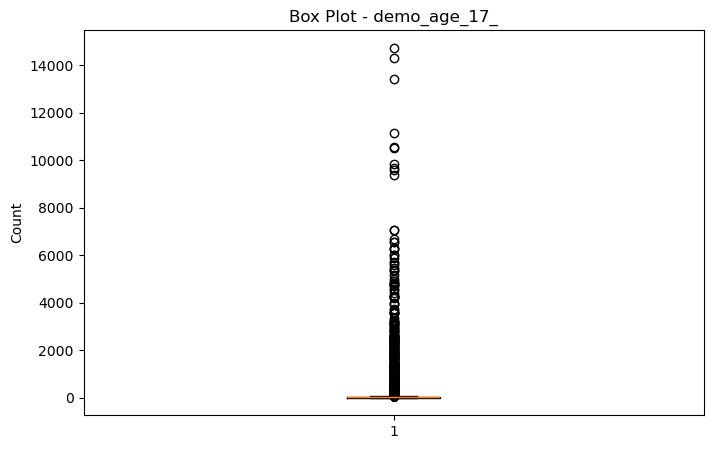

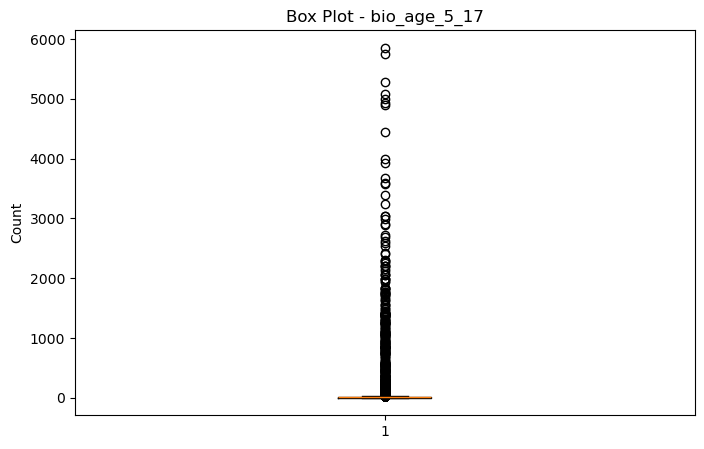

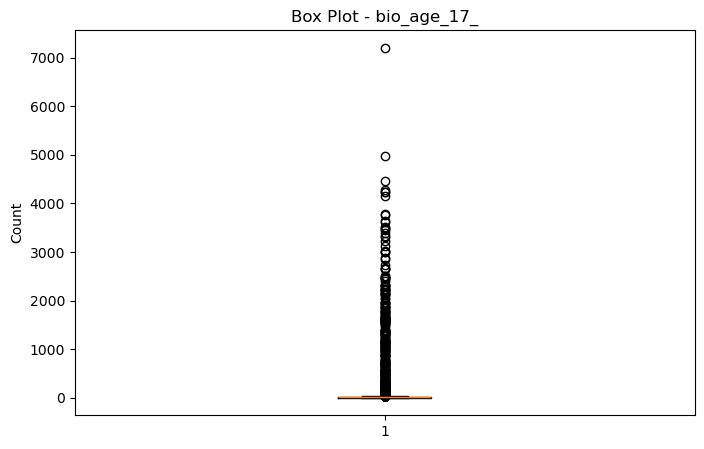

In [29]:
numerical_cols = [
    "age_0_5",
    "age_5_17",
    "age_18_greater",
    "demo_age_5_17",
    "demo_age_17_",
    "bio_age_5_17",
    "bio_age_17_"
]

for col in numerical_cols:
    plt.figure(figsize=(8, 5))

    plt.boxplot(df[col].dropna())

    plt.title(f"Box Plot - {col}")
    plt.ylabel("Count")
    plt.show()


In [30]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")

age_0_5: 7505 outliers
age_5_17: 6384 outliers
age_18_greater: 3481 outliers
demo_age_5_17: 8431 outliers
demo_age_17_: 8084 outliers
bio_age_5_17: 8818 outliers
bio_age_17_: 7330 outliers


## univariate analysis

### Which Aadhaar service dominates the overall demand: New Enrolment, Demographic Updates, or Biometric Updates?

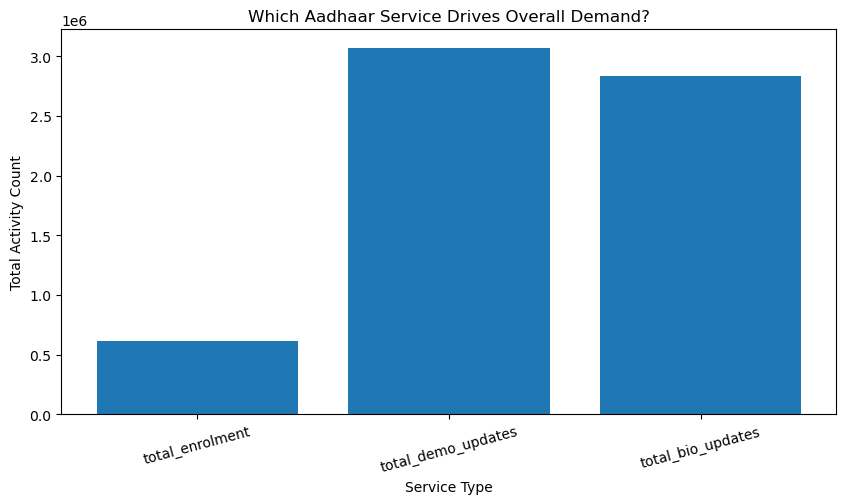

In [31]:
service_cols = [
    'total_enrolment',
    'total_demo_updates',
    'total_bio_updates'
]

plt.figure(figsize=(10, 5))

plt.bar(
    service_cols,
    df[service_cols].sum()
)

plt.title('Which Aadhaar Service Drives Overall Demand?')
plt.xlabel('Service Type')
plt.ylabel('Total Activity Count')

plt.xticks(rotation=15)

plt.show()

### Which age group is driving new Aadhaar enrolment demand?

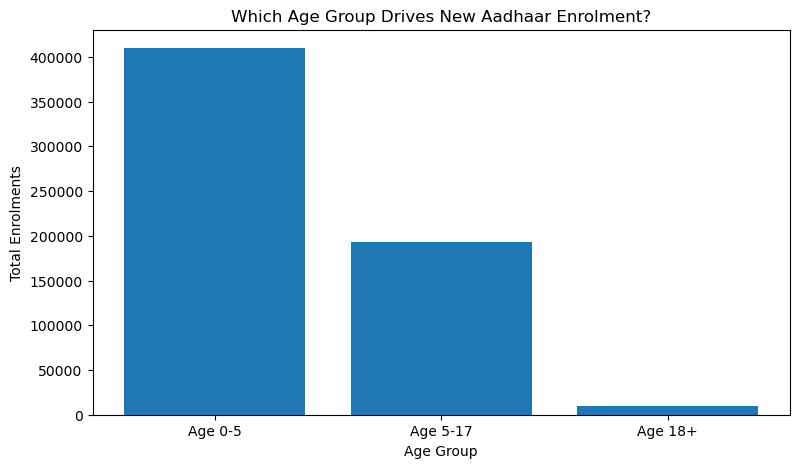

In [32]:
age_cols = [
    'age_0_5',
    'age_5_17',
    'age_18_greater'
]

plt.figure(figsize=(9, 5))

plt.bar(
    ['Age 0-5', 'Age 5-17', 'Age 18+'],
    df[age_cols].sum()
)

plt.title('Which Age Group Drives New Aadhaar Enrolment?')
plt.xlabel('Age Group')
plt.ylabel('Total Enrolments')

plt.show()

## Bivariate analysis

### Where does Aadhaar activity actually happen the most?

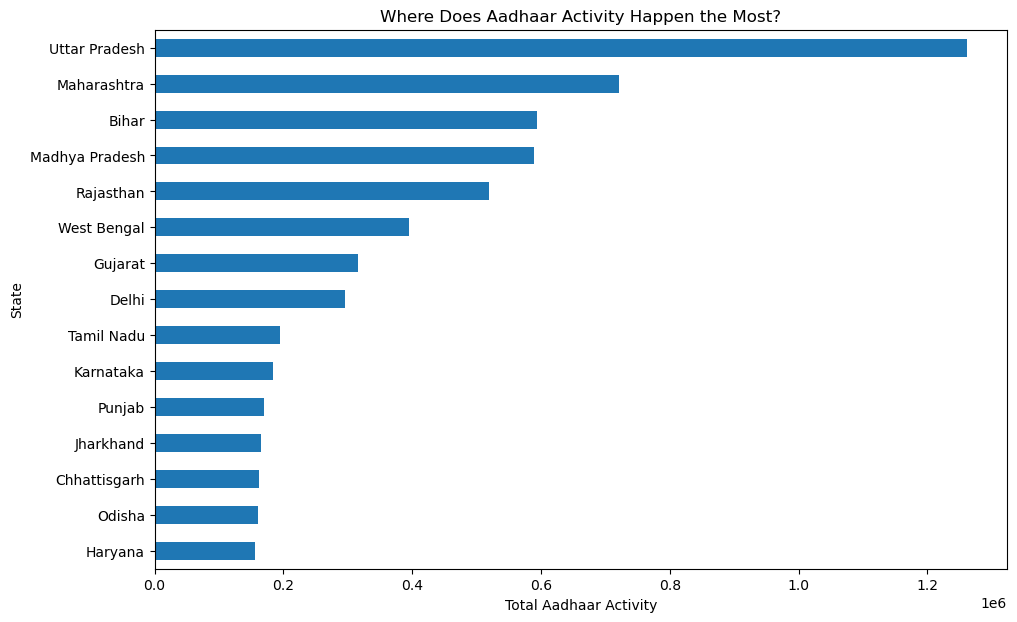

In [33]:
plt.figure(figsize=(11, 7))

df.groupby('state')['total_activity'] \
    .sum() \
    .sort_values(ascending=False) \
    .head(15) \
    .sort_values() \
    .plot(kind='barh')

plt.title('Where Does Aadhaar Activity Happen the Most?')
plt.xlabel('Total Aadhaar Activity')
plt.ylabel('State')

plt.show()

### Which states are enrolment-focused and which are update-focused?

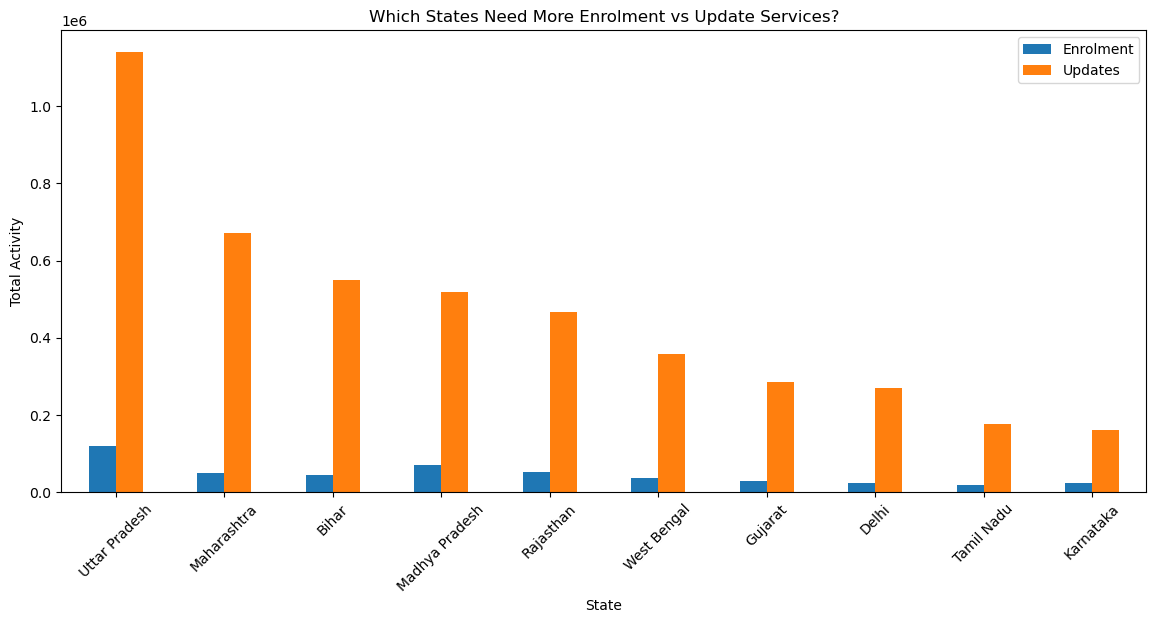

In [34]:
df.groupby('state')[
    ['total_enrolment', 'total_updates']
].sum() \
 .assign(total=lambda x: x['total_enrolment'] + x['total_updates']) \
 .sort_values('total', ascending=False) \
 .head(10)[
     ['total_enrolment', 'total_updates']
 ].plot(
     kind='bar',
     figsize=(14, 6)
 )

plt.title('Which States Need More Enrolment vs Update Services?')
plt.xlabel('State')
plt.ylabel('Total Activity')

plt.xticks(rotation=45)

plt.legend(['Enrolment', 'Updates'])

plt.show()

### How does Aadhaar activity change over the available time period, and are there unusual spikes?

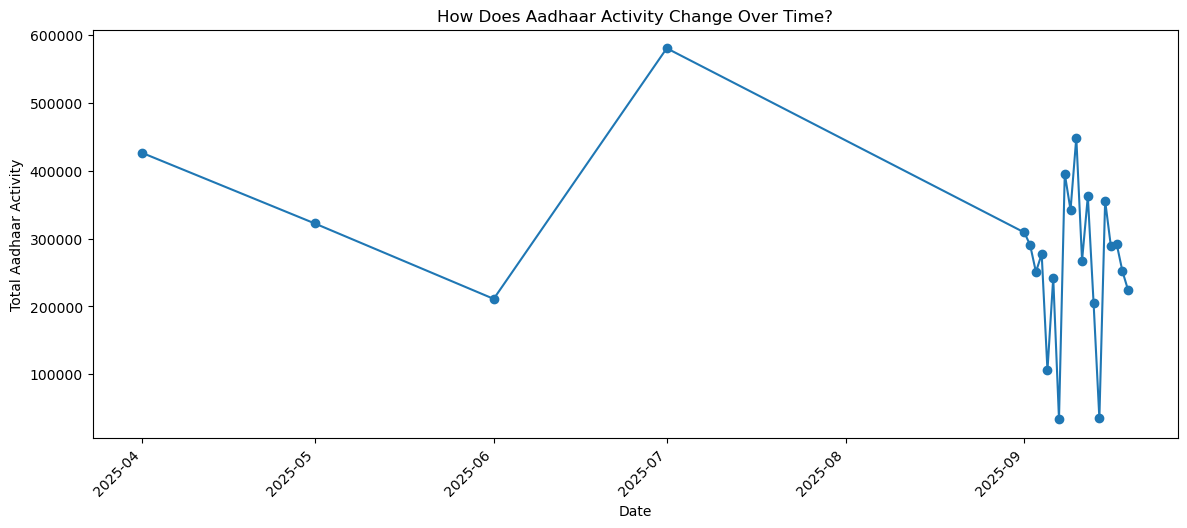

In [35]:
plt.figure(figsize=(14, 6))

df.groupby('date')['total_activity'] \
    .sum() \
    .plot(kind='line', marker='o')

plt.title('How Does Aadhaar Activity Change Over Time?')
plt.xlabel('Date')
plt.ylabel('Total Aadhaar Activity')

plt.xticks(rotation=45)

plt.show()

## Multivariate analysis

### How are different Aadhaar service activities related to each other, and which service demands tend to occur together?

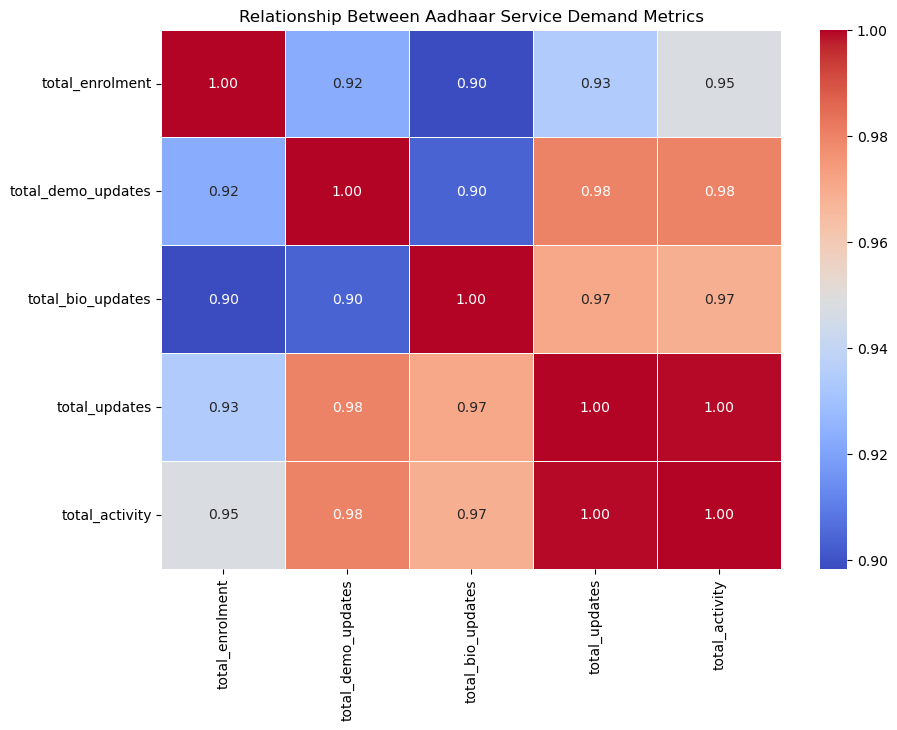

In [36]:
plt.figure(figsize=(10, 7))

multivariate_cols = [
    'total_enrolment',
    'total_demo_updates',
    'total_bio_updates',
    'total_updates',
    'total_activity'
]

sns.heatmap(
    df[multivariate_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Relationship Between Aadhaar Service Demand Metrics')
plt.show()